In [1]:
# Install / upgrade dependencies (run once)
!pip3 install -q 'qiskit>=2.1.0' 'qiskit-ibm-runtime>=0.40.1' 'qiskit-aer>=0.17.0' \
    'numpy' 'pandas' 'matplotlib' 'pylatexenc' 'jinja2'

In [2]:
# ─── Imports ───
import os, json, uuid, warnings
from datetime import datetime
from getpass import getpass
from math import floor, pi, sqrt

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

warnings.filterwarnings("ignore", category=DeprecationWarning)
print("All imports successful.")

All imports successful.


## Configuration

Set experiment parameters here.  All sweeps, paths, and toggles are controlled from this single cell so the notebook is easy to reconfigure without editing experiment code.

In [3]:
# ═══════════════════════════════════════════
# Experiment Configuration
# ═══════════════════════════════════════════

SHOTS          = 1024          # Shots per circuit execution
BACKEND_NAME   = "ibm_marrakesh"   # Preferred backend (None → auto-select least-busy)
RUN_HARDWARE   = True          # Set False to skip real-hardware jobs
OUTPUT_DIR     = "./results/grover"   # Directory for CSV / JSON / PNG artefacts

SEED_TRANSPILER = 42
SEED_SIMULATOR  = 42

# ─── Grover parameters ───
# Map: {num_qubits: marked_state_as_integer}
# Marked states chosen with mixed 0/1 bits to exercise oracle X-flipping logic.
MARKED_STATES = {
    2: 3,    # |11⟩  — search space = 4
    3: 5,    # |101⟩ — search space = 8
    4: 10,   # |1010⟩ — search space = 16
}

# ─── Sweep grids ───
OPT_LEVEL_SWEEP        = [0, 1, 2, 3]       # Transpiler optimisation levels
QUBIT_SWEEP            = [2, 3, 4]           # Search-register sizes
RESILIENCE_LEVEL_SWEEP = [0, 1]              # SamplerV2 resilience levels
DD_SWEEP               = [False, True]       # Dynamical decoupling on / off

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {os.path.abspath(OUTPUT_DIR)}")

Output directory: /Users/destroy/Desktop/MThesis2/Qiskit-v1.1c/results/grover


## Authentication & Backend Selection

Authentication priority:
1. Previously saved IBM Quantum account
2. `apikey.json` in the notebook directory (fallback)
3. Interactive `getpass` prompt

The backend defaults to the value of `BACKEND_NAME`; if it is unavailable or has too few qubits the notebook falls back to the **least-busy** operational backend.

In [4]:
# ─── Authentication ───
service = None

# 1) Try saved account
try:
    service = QiskitRuntimeService()
    print("Loaded saved IBM Quantum account.")
except Exception:
    pass

# 2) Try apikey.json fallback
if service is None:
    for path in ["apikey.json", os.path.join(os.path.dirname(os.path.abspath(".")), "apikey.json")]:
        if os.path.exists(path):
            try:
                with open(path) as f:
                    apidata = json.load(f)
                token = apidata.get("apikey", "")
                if token:
                    QiskitRuntimeService.save_account(
                        channel="ibm_quantum_platform", token=token, overwrite=True
                    )
                    service = QiskitRuntimeService()
                    print(f"Loaded token from {path}")
                    break
            except Exception:
                continue

# 3) Interactive prompt
if service is None:
    token = getpass("Enter your IBM Quantum API token: ")
    QiskitRuntimeService.save_account(
        channel="ibm_quantum_platform", token=token, overwrite=True
    )
    service = QiskitRuntimeService()
    print("Token saved and account loaded.")

# ─── Backend Selection ───
min_qubits = max(QUBIT_SWEEP)

if BACKEND_NAME:
    try:
        backend = service.backend(BACKEND_NAME)
        if backend.num_qubits < min_qubits:
            print(f"WARNING: {BACKEND_NAME} has only {backend.num_qubits} qubits "
                  f"(need >= {min_qubits}). Falling back to least_busy.")
            backend = service.least_busy(
                operational=True, simulator=False, min_num_qubits=min_qubits
            )
    except Exception as e:
        print(f"WARNING: {BACKEND_NAME} unavailable ({e}). Falling back to least_busy.")
        backend = service.least_busy(
            operational=True, simulator=False, min_num_qubits=min_qubits
        )
else:
    backend = service.least_busy(
        operational=True, simulator=False, min_num_qubits=min_qubits
    )

print(f"Selected backend: {backend.name} ({backend.num_qubits} qubits)")

qiskit_runtime_service.__init__:WARNING:2026-04-01 06:26:52,611: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Qiskit-GRM. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-01 06:26:52,614: Using instance: Qiskit-GRM, plan: open


Loaded saved IBM Quantum account.
Selected backend: ibm_marrakesh (156 qubits)


---
## Grover's Algorithm Circuit Components

Grover's search algorithm finds a marked item in an unstructured database of $N = 2^n$ items using $O(\sqrt{N})$ queries — a quadratic speedup over classical brute-force search.

The algorithm consists of three building blocks:

| Function | Purpose |
|---|---|
| `build_oracle(n, marked)` | Phase-flip oracle: negate the amplitude of the marked state |
| `build_diffusion(n)` | Grover diffusion operator: reflect about the uniform superposition $2|s\rangle\langle s| - I$ |
| `optimal_num_iterations(n, m)` | Compute $\lfloor \frac{\pi}{4} \sqrt{N/M} \rfloor$ optimal iterations |

Each Grover iteration applies Oracle → Diffusion, amplifying the probability of measuring the marked state.

In [5]:
def build_oracle(num_qubits, marked_state):
    """
    Phase-flip oracle: applies a phase of -1 to the marked state.

    Implementation:
    1. X-flip qubits where the marked state has bit value 0
       (so the target maps to |11...1⟩)
    2. Multi-controlled Z gate (H-MCX-H on last qubit)
    3. Un-flip the X gates from step 1

    Parameters
    ----------
    num_qubits   : int   Number of qubits.
    marked_state : int   Integer value of the state to mark.

    Returns
    -------
    Gate  (named "Oracle")
    """
    qc = QuantumCircuit(num_qubits)
    bitstring = format(marked_state, f'0{num_qubits}b')

    # Flip qubits where the marked state has a 0
    # Note: bitstring[0] is the MSB = qubit (num_qubits-1)
    flip_qubits = []
    for i, bit in enumerate(reversed(bitstring)):
        if bit == '0':
            flip_qubits.append(i)
            qc.x(i)

    # Multi-controlled Z = H on target, MCX, H on target
    target = num_qubits - 1
    controls = list(range(num_qubits - 1))
    qc.h(target)
    qc.mcx(controls, target)
    qc.h(target)

    # Un-flip
    for i in flip_qubits:
        qc.x(i)

    oracle_gate = qc.to_gate()
    oracle_gate.name = "Oracle"
    return oracle_gate

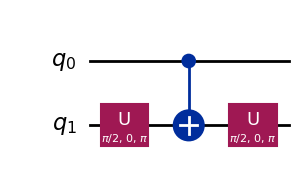

In [6]:
# Oracle visualisation — 2 qubits, marking |11⟩ = 3
oracle_2q = build_oracle(2, 3)
circ = QuantumCircuit(2)
circ.compose(oracle_2q, inplace=True)
circ.decompose(reps=2).draw(output="mpl", fold=-1)

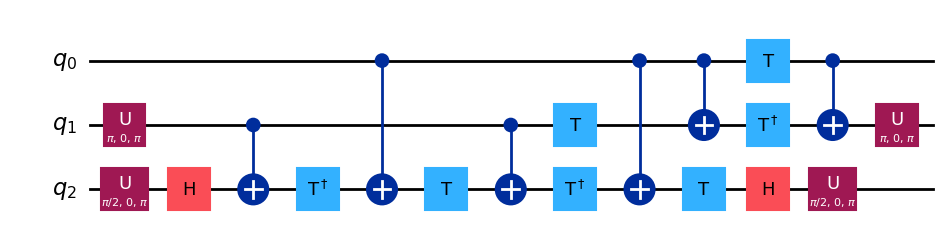

In [7]:
# Oracle visualisation — 3 qubits, marking |101⟩ = 5
oracle_3q = build_oracle(3, 5)
circ = QuantumCircuit(3)
circ.compose(oracle_3q, inplace=True)
circ.decompose(reps=2).draw(output="mpl", fold=-1)

In [8]:
def build_diffusion(num_qubits):
    """
    Grover diffusion operator: 2|s⟩⟨s| - I

    Implementation:
    H-all → X-all → multi-controlled Z → X-all → H-all

    Parameters
    ----------
    num_qubits : int   Number of qubits.

    Returns
    -------
    Gate  (named "Diffusion")
    """
    qc = QuantumCircuit(num_qubits)

    qc.h(range(num_qubits))
    qc.x(range(num_qubits))

    # Multi-controlled Z
    target = num_qubits - 1
    controls = list(range(num_qubits - 1))
    qc.h(target)
    qc.mcx(controls, target)
    qc.h(target)

    qc.x(range(num_qubits))
    qc.h(range(num_qubits))

    diff_gate = qc.to_gate()
    diff_gate.name = "Diffusion"
    return diff_gate

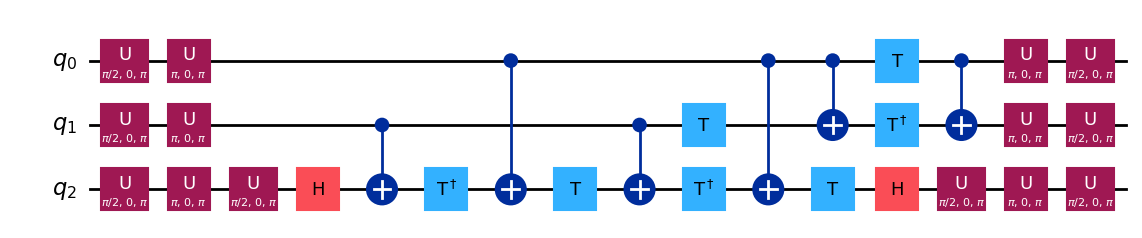

In [9]:
# Diffusion visualisation — 3 qubits
diff_3q = build_diffusion(3)
circ = QuantumCircuit(3)
circ.compose(diff_3q, inplace=True)
circ.decompose(reps=2).draw(output="mpl", fold=-1)

In [10]:
def optimal_num_iterations(num_qubits, num_marked=1):
    """Compute the optimal number of Grover iterations: floor(pi/4 * sqrt(N/M))."""
    N = 2 ** num_qubits
    return max(1, floor(pi / 4 * sqrt(N / num_marked)))


# Demonstrate iteration counts
print("Optimal Grover iterations for 1 marked item:")
print(f"{'Qubits':>6}  {'Search Space':>12}  {'Iterations':>10}")
print("-" * 34)
for n in [2, 3, 4, 5]:
    k = optimal_num_iterations(n)
    print(f"{n:>6}  {2**n:>12}  {k:>10}")

Optimal Grover iterations for 1 marked item:
Qubits  Search Space  Iterations
----------------------------------
     2             4           1
     3             8           2
     4            16           3
     5            32           4


In [11]:
def theoretical_success_prob(num_qubits, num_iterations, num_marked=1):
    """Exact theoretical success probability after k Grover iterations."""
    N = 2 ** num_qubits
    theta = np.arcsin(np.sqrt(num_marked / N))
    return float(np.sin((2 * num_iterations + 1) * theta) ** 2)


print("Theoretical success probabilities:")
print(f"{'Qubits':>6}  {'Iterations':>10}  {'Success Prob':>12}")
print("-" * 34)
for n in QUBIT_SWEEP:
    k = optimal_num_iterations(n)
    p = theoretical_success_prob(n, k)
    print(f"{n:>6}  {k:>10}  {p:>12.4f}")

Theoretical success probabilities:
Qubits  Iterations  Success Prob
----------------------------------
     2           1        1.0000
     3           2        0.9453
     4           3        0.9613


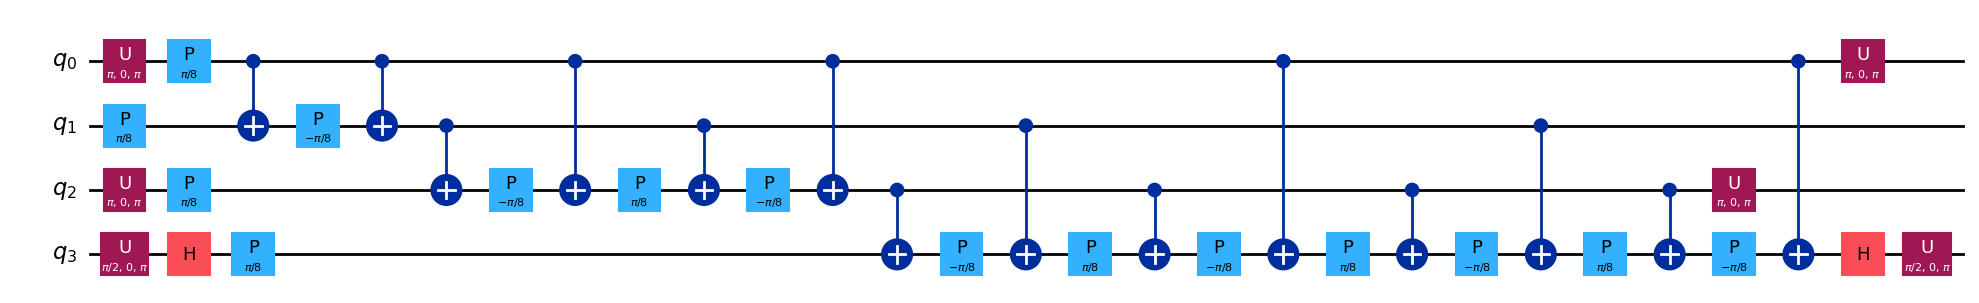

In [12]:
# Oracle visualisation — 4 qubits, marking |1010⟩ = 10
oracle_4q = build_oracle(4, 10)
circ = QuantumCircuit(4)
circ.compose(oracle_4q, inplace=True)
circ.decompose(reps=2).draw(output="mpl", fold=-1)

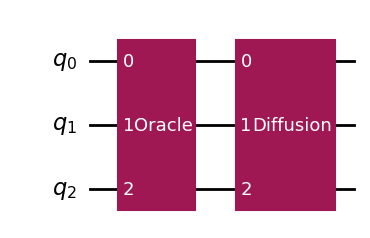

In [13]:
# Single Grover iteration = Oracle + Diffusion (3-qubit example)
circ = QuantumCircuit(3)
circ.compose(build_oracle(3, 5), inplace=True)
circ.compose(build_diffusion(3), inplace=True)
circ.draw(output="mpl", fold=-1)

Full Grover circuit: 3 qubits, 2 iterations, marking |101⟩


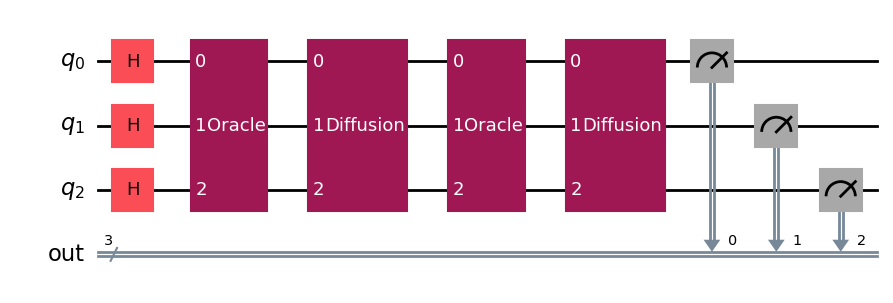

In [14]:
# Full Grover circuit — 3 qubits, marking |101⟩ = 5, 2 iterations
n_demo = 3
marked_demo = 5
iters_demo = optimal_num_iterations(n_demo)

qr = QuantumRegister(n_demo, name="q")
cr = ClassicalRegister(n_demo, name="out")
demo_qc = QuantumCircuit(qr, cr)

# Uniform superposition
demo_qc.h(range(n_demo))

# Grover iterations
for _ in range(iters_demo):
    demo_qc.compose(build_oracle(n_demo, marked_demo), inplace=True)
    demo_qc.compose(build_diffusion(n_demo), inplace=True)

# Measure
demo_qc.measure(qr, cr)

print(f"Full Grover circuit: {n_demo} qubits, {iters_demo} iterations, "
      f"marking |{format(marked_demo, f'0{n_demo}b')}⟩")
demo_qc.draw(output="mpl", fold=-1)

In [15]:
# Verify with ideal simulation
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler(seed=SEED_SIMULATOR)
job = sampler.run([demo_qc], shots=10_000)
result = job.result()[0]
counts = result.data.out.get_counts()

marked_bs = format(marked_demo, f'0{n_demo}b')
total = sum(counts.values())
print(f"Marked state |{marked_bs}⟩ measured {counts.get(marked_bs, 0)} / {total} times "
      f"({counts.get(marked_bs, 0)/total:.2%})")
print(f"Top 5 outcomes: {dict(sorted(counts.items(), key=lambda x: -x[1])[:5])}")

Marked state |101⟩ measured 9438 / 10000 times (94.38%)
Top 5 outcomes: {'101': 9438, '000': 86, '011': 85, '100': 85, '111': 85}


---
## Experiment Helper Functions

| Function | Purpose |
|---|---|
| `build_grover_circuit(num_qubits, ...)` | Build the search circuit for configurable qubit count |
| `transpile_for_backend(circuit, backend, opt_level, ...)` | Transpile and return 2-qubit depth / gate count |
| `run_ideal(circuit, shots)` | Noiseless simulation (100k shots) |
| `run_noisy(circuit, backend, shots)` | Noisy simulation (device noise model or generic fallback) |
| `run_hardware(transpiled, backend, shots, ...)` | Submit to IBM hardware via SamplerV2 |
| `compute_grover_metrics(dist, ideal_dist, noisy_dist, ...)` | TVD, success probability, amplification ratio |

In [16]:
def build_grover_circuit(num_qubits, marked_state=None):
    """
    Build the complete Grover search circuit.

    Parameters
    ----------
    num_qubits   : int   Number of qubits (search space = 2^num_qubits).
    marked_state : int   Integer value of the state to find.
                         Defaults to 2^num_qubits - 1 (all-ones).

    Returns
    -------
    QuantumCircuit with registers q and out (classical).
    """
    if marked_state is None:
        marked_state = 2 ** num_qubits - 1

    num_iter = optimal_num_iterations(num_qubits)

    qr = QuantumRegister(num_qubits, name="q")
    cr = ClassicalRegister(num_qubits, name="out")  # MUST be "out" for run_ideal/run_hardware
    qc = QuantumCircuit(qr, cr)

    # Uniform superposition
    qc.h(range(num_qubits))

    # Grover iterations
    oracle = build_oracle(num_qubits, marked_state)
    diffusion = build_diffusion(num_qubits)

    for _ in range(num_iter):
        qc.compose(oracle, inplace=True)
        qc.compose(diffusion, inplace=True)

    # Measure all qubits
    qc.measure(qr, cr)

    return qc


# Sanity check
for nq in QUBIT_SWEEP:
    _qc = build_grover_circuit(nq, MARKED_STATES[nq])
    _k = optimal_num_iterations(nq)
    print(f"build_grover_circuit({nq}q, marked={MARKED_STATES[nq]}): "
          f"{_qc.num_qubits} qubits, {_qc.num_clbits} clbits, {_k} iterations")

build_grover_circuit(2q, marked=3): 2 qubits, 2 clbits, 1 iterations
build_grover_circuit(3q, marked=5): 3 qubits, 3 clbits, 2 iterations
build_grover_circuit(4q, marked=10): 4 qubits, 4 clbits, 3 iterations


In [17]:
def transpile_for_backend(circuit, backend, optimization_level, seed=SEED_TRANSPILER):
    """
    Transpile *circuit* for *backend* and return (transpiled_circuit, metrics_dict).
    """
    pm = generate_preset_pass_manager(
        optimization_level=optimization_level,
        backend=backend,
        seed_transpiler=seed,
    )
    tc = pm.run(circuit)

    metrics = {
        "depth_2q":    tc.depth(lambda x: x.operation.num_qubits == 2),
        "count_2q":    tc.size(lambda x: x.operation.num_qubits == 2),
        "total_depth": tc.depth(),
    }
    return tc, metrics

In [18]:
def run_ideal(circuit, shots=100_000, seed=SEED_SIMULATOR):
    """
    Tier A — ideal (noiseless) simulation via StatevectorSampler.

    Uses Qiskit's built-in StatevectorSampler for exact noiseless sampling.

    Returns
    -------
    dict  {bitstring: probability}
    """
    from qiskit.primitives import StatevectorSampler

    sampler = StatevectorSampler(seed=seed)
    job     = sampler.run([circuit], shots=shots)
    result  = job.result()[0]

    counts = result.data.out.get_counts()
    total  = sum(counts.values())
    return {k: v / total for k, v in counts.items()}

In [19]:
def run_noisy(circuit, backend, shots=SHOTS, seed=SEED_SIMULATOR):
    """
    Tier B — noisy simulation via AerSimulator.

    Attempts to build a noise model from the real backend.
    Falls back to a simple depolarising model if that fails.

    Returns
    -------
    dict  {bitstring: probability}   (or empty dict on total failure)
    """
    from qiskit_aer import AerSimulator
    from qiskit_aer.noise import NoiseModel, depolarizing_error

    noise_model = None
    noise_source = "none"

    # Attempt 1: real-backend noise model
    try:
        noise_model = NoiseModel.from_backend(backend)
        noise_source = "backend"
    except Exception as e:
        print(f"  Could not build noise model from backend: {e}")

    # Attempt 2: generic depolarising fallback
    if noise_model is None or len(noise_model.to_dict().get("errors", [])) == 0:
        try:
            noise_model = NoiseModel()
            # 1-qubit depolarising error ~0.1 %
            err_1q = depolarizing_error(0.001, 1)
            # 2-qubit depolarising error ~1 %
            err_2q = depolarizing_error(0.01, 2)
            noise_model.add_all_qubit_quantum_error(err_1q, ["u1", "u2", "u3", "sx", "x", "rz"])
            noise_model.add_all_qubit_quantum_error(err_2q, ["cx", "ecr", "cz"])
            noise_source = "generic-depolarising"
            print(f"  Using generic depolarising noise model.")
        except Exception as e2:
            print(f"  Noisy simulation unavailable: {e2}")
            return {}

    sim = AerSimulator(noise_model=noise_model, seed_simulator=seed)
    pm  = generate_preset_pass_manager(optimization_level=0, backend=sim)
    tc  = pm.run(circuit)

    # Use AerSimulator.run() directly (reliable across Aer versions)
    result = sim.run(tc, shots=shots).result()
    counts = result.get_counts()
    total  = sum(counts.values())
    dist   = {k: v / total for k, v in counts.items()}
    return dist

In [20]:
def run_hardware(transpiled_circuit, backend, shots=SHOTS,
                 resilience_level=0, dd_enable=False):
    """
    Tier C — real IBM hardware via SamplerV2.

    Parameters
    ----------
    transpiled_circuit : QuantumCircuit  (already transpiled for backend)
    backend            : IBMBackend
    shots              : int
    resilience_level   : int             0 or 1
    dd_enable          : bool            enable dynamical decoupling

    Returns
    -------
    (distribution_dict, job_id_str)
    """
    sampler = Sampler(mode=backend)

    # ── Runtime options ──
    try:
        sampler.options.default_shots = shots
    except Exception:
        pass

    try:
        sampler.options.resilience_level = resilience_level
    except Exception:
        pass

    if dd_enable:
        try:
            sampler.options.dynamical_decoupling.enable = True
            sampler.options.dynamical_decoupling.sequence_type = "XpXm"
        except Exception:
            pass

    try:
        sampler.options.twirling.enable_gates = True
    except Exception:
        pass

    job = sampler.run([transpiled_circuit], shots=shots)
    job_id = job.job_id()
    print(f"  Submitted job {job_id} on {backend.name}")

    result = job.result()[0]
    counts = result.data.out.get_counts()
    total  = sum(counts.values())
    dist   = {k: v / total for k, v in counts.items()}

    return dist, job_id

In [21]:
def compute_grover_metrics(dist, ideal_dist, noisy_dist,
                           num_qubits, marked_state):
    """
    Compute thesis metrics for one Grover experiment run.

    Returns
    -------
    dict with keys: tvd_vs_ideal, tvd_vs_noisy, tvd_noisy_vs_ideal,
                    success_prob, amplification, marked_bitstring, random_baseline
    """
    # ── Total Variation Distance ──
    def tvd(p, q):
        all_keys = set(p) | set(q)
        return 0.5 * sum(abs(p.get(k, 0.0) - q.get(k, 0.0)) for k in all_keys)

    tvd_vs_ideal    = tvd(dist, ideal_dist)
    tvd_vs_noisy    = tvd(dist, noisy_dist) if noisy_dist else None
    tvd_noisy_ideal = tvd(noisy_dist, ideal_dist) if noisy_dist else None

    # ── Success probability: prob of measuring the marked state ──
    marked_bitstring = format(marked_state, f'0{num_qubits}b')
    success_prob = dist.get(marked_bitstring, 0.0)

    # ── Amplification ratio vs random guessing ──
    random_baseline = 1.0 / (2 ** num_qubits)
    amplification = success_prob / random_baseline if random_baseline > 0 else 0.0

    return {
        "tvd_vs_ideal":       round(tvd_vs_ideal, 6),
        "tvd_vs_noisy":       round(tvd_vs_noisy, 6) if tvd_vs_noisy is not None else None,
        "tvd_noisy_vs_ideal": round(tvd_noisy_ideal, 6) if tvd_noisy_ideal is not None else None,
        "success_prob":       round(success_prob, 6),
        "marked_bitstring":   marked_bitstring,
        "random_baseline":    round(random_baseline, 6),
        "amplification":      round(amplification, 4),
    }

---
## Benchmarking Tiers

| Tier | Description |
|------|-------------|
| **A — Ideal** | Noiseless simulation (100k shots). Establishes the theoretical baseline. |
| **B — Noisy** | Aer simulation with a device-derived noise model (or generic depolarising fallback). Models the main error channels without queue wait. |
| **C — Hardware** | Real IBM Quantum hardware via SamplerV2 with configurable resilience and dynamical decoupling. |

### Metrics

| Metric | Meaning |
|--------|---------|
| **TVD** (Total Variation Distance) | $\text{TVD}(P,Q) = \frac{1}{2}\sum_x |P(x)-Q(x)|$.  Ranges 0 (identical) to 1 (fully disjoint). |
| **Success probability** | Probability of measuring the **marked state** (single bitstring). |
| **Amplification** | $\text{success\_prob} \;/\; (1/2^n)$ — fold-improvement over random guessing. Ideal Grover achieves amplification ≈ N. |

## Experiment Sweeps

The loop below runs the **same** Grover circuit through every combination of:

| Axis | Values | What it tests |
|------|--------|---------------|
| Optimisation level | 0, 1, 2, 3 | Compiler aggressiveness (circuit depth vs fidelity) |
| Search-register qubits | 2, 3, 4 | Search space size (4, 8, 16) and Grover iterations (1, 2, 3) |
| Resilience level | 0, 1 | IBM error-mitigation overhead (SamplerV2 option) |
| Dynamical decoupling | Off, On | Idle-qubit decoherence suppression |

Every configuration is run on all three tiers (ideal / noisy / hardware) and the results are stored in a DataFrame for subsequent analysis.

In [22]:
# ═══════════════════════════════════════════
# Run All Experiments
# ═══════════════════════════════════════════

all_results = []   # list of dicts → DataFrame later
all_distributions = {}  # run_id → {tier: distribution}
run_counter = 0

for nq in QUBIT_SWEEP:
    marked = MARKED_STATES[nq]
    num_iter = optimal_num_iterations(nq)

    # 1) Build circuit
    qc = build_grover_circuit(num_qubits=nq, marked_state=marked)
    print(f"\n{'='*60}")
    print(f"Qubits = {nq}  (search space = {2**nq}, "
          f"iterations = {num_iter}, marked = |{format(marked, f'0{nq}b')}⟩)")
    print(f"{'='*60}")

    # 2) Ideal distribution (computed once per qubit count)
    print("  [Tier A] Ideal simulation …")
    ideal_dist = run_ideal(qc, shots=100_000, seed=SEED_SIMULATOR)
    marked_bs = format(marked, f'0{nq}b')
    print(f"    → P(|{marked_bs}⟩) = {ideal_dist.get(marked_bs, 0.0):.4f}")

    # 3) Noisy distribution (once per qubit count)
    print("  [Tier B] Noisy simulation …")
    noisy_dist = run_noisy(qc, backend, shots=SHOTS, seed=SEED_SIMULATOR)
    if noisy_dist:
        print(f"    → P(|{marked_bs}⟩) = {noisy_dist.get(marked_bs, 0.0):.4f}")
    else:
        print(f"    → skipped (no noise model available)")

    for opt_level in OPT_LEVEL_SWEEP:
        # 4) Transpile
        tc, t_metrics = transpile_for_backend(qc, backend, opt_level, seed=SEED_TRANSPILER)
        print(f"\n  opt_level={opt_level}  2q-depth={t_metrics['depth_2q']}  "
              f"2q-count={t_metrics['count_2q']}")

        for res_level in RESILIENCE_LEVEL_SWEEP:
            for dd in DD_SWEEP:
                run_counter += 1
                run_id = f"run-{run_counter:04d}"
                ts = datetime.utcnow().isoformat() + "Z"

                row = {
                    "run_id":           run_id,
                    "timestamp":        ts,
                    "num_qubits":       nq,
                    "num_iterations":   num_iter,
                    "marked_state":     marked,
                    "search_space":     2 ** nq,
                    "opt_level":        opt_level,
                    "resilience_level": res_level,
                    "dd_enable":        dd,
                    "shots":            SHOTS,
                    "backend":          backend.name,
                    "depth_2q":         t_metrics["depth_2q"],
                    "count_2q":         t_metrics["count_2q"],
                    "total_depth":      t_metrics["total_depth"],
                }

                # Ideal metrics (same ideal_dist reused)
                ideal_metrics = compute_grover_metrics(
                    ideal_dist, ideal_dist, noisy_dist, nq, marked
                )
                row["ideal_success_prob"]  = ideal_metrics["success_prob"]
                row["ideal_amplification"] = ideal_metrics["amplification"]

                # Noisy metrics
                if noisy_dist:
                    noisy_metrics = compute_grover_metrics(
                        noisy_dist, ideal_dist, noisy_dist, nq, marked
                    )
                    row["noisy_success_prob"]  = noisy_metrics["success_prob"]
                    row["tvd_noisy_vs_ideal"]  = noisy_metrics["tvd_vs_ideal"]
                else:
                    row["noisy_success_prob"] = None
                    row["tvd_noisy_vs_ideal"] = None

                # Hardware run
                if RUN_HARDWARE:
                    tag = f"res={res_level} dd={'ON' if dd else 'OFF'}"
                    print(f"    [{run_id}] Hardware: opt={opt_level} {tag} …")
                    try:
                        hw_dist, job_id = run_hardware(
                            tc, backend, shots=SHOTS,
                            resilience_level=res_level, dd_enable=dd,
                        )
                        hw_metrics = compute_grover_metrics(
                            hw_dist, ideal_dist, noisy_dist, nq, marked
                        )
                        row["hw_success_prob"]    = hw_metrics["success_prob"]
                        row["tvd_hw_vs_ideal"]    = hw_metrics["tvd_vs_ideal"]
                        row["tvd_hw_vs_noisy"]    = hw_metrics["tvd_vs_noisy"]
                        row["hw_amplification"]   = hw_metrics["amplification"]
                        row["job_id"]             = job_id
                        all_distributions[run_id] = {
                            "ideal": ideal_dist,
                            "noisy": noisy_dist,
                            "hardware": hw_dist,
                        }
                        print(f"      success_prob={hw_metrics['success_prob']:.4f}  "
                              f"tvd_hw_ideal={hw_metrics['tvd_vs_ideal']:.4f}  "
                              f"amplification={hw_metrics['amplification']:.2f}x")
                    except Exception as e:
                        print(f"      ERROR: {e}")
                        row["hw_success_prob"]  = None
                        row["tvd_hw_vs_ideal"]  = None
                        row["tvd_hw_vs_noisy"]  = None
                        row["hw_amplification"] = None
                        row["job_id"]           = None
                else:
                    row["hw_success_prob"]  = None
                    row["tvd_hw_vs_ideal"]  = None
                    row["tvd_hw_vs_noisy"]  = None
                    row["hw_amplification"] = None
                    row["job_id"]           = None

                all_results.append(row)

print(f"\nDone — {len(all_results)} experiment rows collected.")


Qubits = 2  (search space = 4, iterations = 1, marked = |11⟩)
  [Tier A] Ideal simulation …
    → P(|11⟩) = 1.0000
  [Tier B] Noisy simulation …
    → P(|11⟩) = 0.9688

  opt_level=0  2q-depth=2  2q-count=2
    [run-0001] Hardware: opt=0 res=0 dd=OFF …
  Submitted job d76853u8faus73f0v1f0 on ibm_marrakesh
      success_prob=0.9727  tvd_hw_ideal=0.0273  amplification=3.89x
    [run-0002] Hardware: opt=0 res=0 dd=ON …
  Submitted job d76855m8faus73f0v1h0 on ibm_marrakesh
      success_prob=0.9629  tvd_hw_ideal=0.0371  amplification=3.85x
    [run-0003] Hardware: opt=0 res=1 dd=OFF …
  Submitted job d7685a68faus73f0v1n0 on ibm_marrakesh
      success_prob=0.9600  tvd_hw_ideal=0.0400  amplification=3.84x
    [run-0004] Hardware: opt=0 res=1 dd=ON …
  Submitted job d7685ce8faus73f0v1q0 on ibm_marrakesh
      success_prob=0.9756  tvd_hw_ideal=0.0244  amplification=3.90x

  opt_level=1  2q-depth=2  2q-count=2
    [run-0005] Hardware: opt=1 res=0 dd=OFF …
  Submitted job d7685enq1anc738d92c0 

---
## Results & Analysis

In [24]:
# ─── Build DataFrame ───
df = pd.DataFrame(all_results)
display(df)

# ─── Export CSV ───
csv_path = os.path.join(OUTPUT_DIR, "grover_results.csv")
df.to_csv(csv_path, index=False)
print(f"Saved {csv_path}")

# ─── Export JSON (includes raw distributions + metadata) ───
json_payload = {
    "created": datetime.utcnow().isoformat() + "Z",
    "backend": backend.name,
    "grover_params": {"marked_states": {str(k): v for k, v in MARKED_STATES.items()}},
    "runs": all_results,
    "distributions": {
        rid: {tier: dist for tier, dist in tiers.items()}
        for rid, tiers in all_distributions.items()
    },
}
json_path = os.path.join(OUTPUT_DIR, "grover_results.json")
with open(json_path, "w") as f:
    json.dump(json_payload, f, indent=2, default=str)
print(f"Saved {json_path}")

,run_id,timestamp,num_qubits,num_iterations,marked_state,search_space,opt_level,resilience_level,dd_enable,shots,...,total_depth,ideal_success_prob,ideal_amplification,noisy_success_prob,tvd_noisy_vs_ideal,hw_success_prob,tvd_hw_vs_ideal,tvd_hw_vs_noisy,hw_amplification,job_id
0,run-0001,2026-04-01T02:27:26.305433Z,2,1,3,4,0,0,False,1024,...,38,1.00000,4.0000,0.968750,0.031250,0.972656,0.027344,0.003906,3.8906,d76853u8faus73f0v1f0
1,run-0002,2026-04-01T02:27:34.045673Z,2,1,3,4,0,0,True,1024,...,38,1.00000,4.0000,0.968750,0.031250,0.962891,0.037109,0.005859,3.8516,d76855m8faus73f0v1h0
2,run-0003,2026-04-01T02:27:51.722583Z,2,1,3,4,0,1,False,1024,...,38,1.00000,4.0000,0.968750,0.031250,0.959961,0.040039,0.015625,3.8398,d7685a68faus73f0v1n0
3,run-0004,2026-04-01T02:28:00.291263Z,2,1,3,4,0,1,True,1024,...,38,1.00000,4.0000,0.968750,0.031250,0.975586,0.024414,0.009766,3.9023,d7685ce8faus73f0v1q0
4,run-0005,2026-04-01T02:28:09.559382Z,2,1,3,4,1,0,False,1024,...,12,1.00000,4.0000,0.968750,0.031250,0.963867,0.036133,0.008789,3.8555,d7685enq1anc738d92c0
5,run-0006,2026-04-01T02:28:18.506627Z,2,1,3,4,1,0,True,1024,...,12,1.00000,4.0000,0.968750,0.031250,0.965820,0.034180,0.010742,3.8633,d7685gu8faus73f0v20g
6,run-0007,2026-04-01T02:28:28.421773Z,2,1,3,4,1,1,False,1024,...,12,1.00000,4.0000,0.968750,0.031250,0.955078,0.044922,0.013672,3.8203,d7685ja3qcgc73fsks4g
7,run-0008,2026-04-01T02:28:37.550856Z,2,1,3,4,1,1,True,1024,...,12,1.00000,4.0000,0.968750,0.031250,0.976562,0.023438,0.012695,3.9062,d7685llbjrds73ed9m20
8,run-0009,2026-04-01T02:28:45.376488Z,2,1,3,4,2,0,False,1024,...,10,1.00000,4.0000,0.968750,0.031250,0.898438,0.101562,0.073242,3.5938,d7685nm8faus73f0v2a0
9,run-0010,2026-04-01T02:28:52.322337Z,2,1,3,4,2,0,True,1024,...,10,1.00000,4.0000,0.968750,0.031250,0.895508,0.104492,0.080078,3.5820,d7685pa3qcgc73fsksc0


Saved ./results/grover/grover_results.csv
Saved ./results/grover/grover_results.json


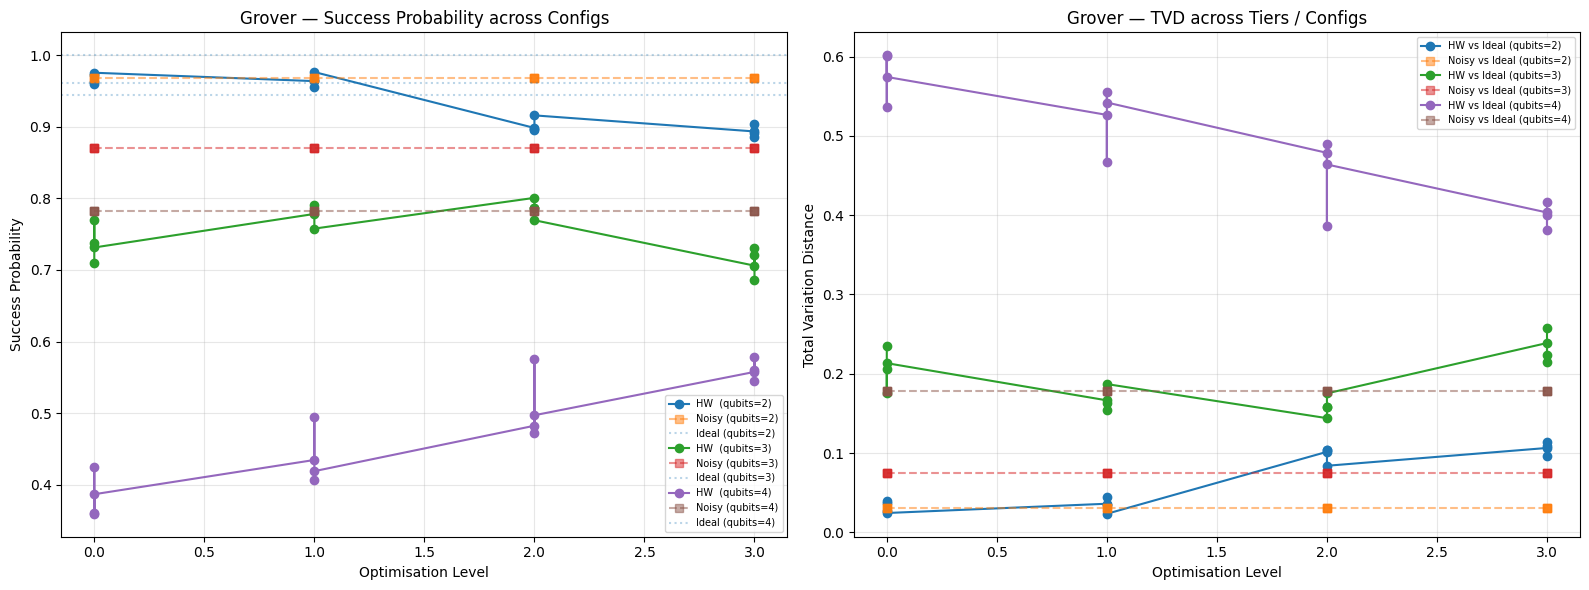

Saved ./results/grover/success_prob_and_tvd.png


In [25]:
# ═══════════════════════════════════════════
# Plots  (all from computed data — nothing invented)
# ═══════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ─── Plot 1: Success Probability ───
ax = axes[0]
for nq in QUBIT_SWEEP:
    sub = df[df["num_qubits"] == nq]
    if sub["hw_success_prob"].notna().any():
        ax.plot(sub["opt_level"], sub["hw_success_prob"],
                marker="o", label=f"HW  (qubits={nq})")
    if sub["noisy_success_prob"].notna().any():
        ax.plot(sub["opt_level"], sub["noisy_success_prob"],
                marker="s", linestyle="--", alpha=0.5, label=f"Noisy (qubits={nq})")
    if sub["ideal_success_prob"].notna().any():
        ax.axhline(sub["ideal_success_prob"].iloc[0],
                   linestyle=":", alpha=0.3, label=f"Ideal (qubits={nq})")
ax.set_xlabel("Optimisation Level")
ax.set_ylabel("Success Probability")
ax.set_title("Grover — Success Probability across Configs")
ax.legend(fontsize=7, loc="best")
ax.grid(True, alpha=0.3)

# ─── Plot 2: TVD ───
ax = axes[1]
for nq in QUBIT_SWEEP:
    sub = df[df["num_qubits"] == nq]
    if sub["tvd_hw_vs_ideal"].notna().any():
        ax.plot(sub["opt_level"], sub["tvd_hw_vs_ideal"],
                marker="o", label=f"HW vs Ideal (qubits={nq})")
    if sub["tvd_noisy_vs_ideal"].notna().any():
        ax.plot(sub["opt_level"], sub["tvd_noisy_vs_ideal"],
                marker="s", linestyle="--", alpha=0.5, label=f"Noisy vs Ideal (qubits={nq})")
ax.set_xlabel("Optimisation Level")
ax.set_ylabel("Total Variation Distance")
ax.set_title("Grover — TVD across Tiers / Configs")
ax.legend(fontsize=7, loc="best")
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "success_prob_and_tvd.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {os.path.join(OUTPUT_DIR, 'success_prob_and_tvd.png')}")

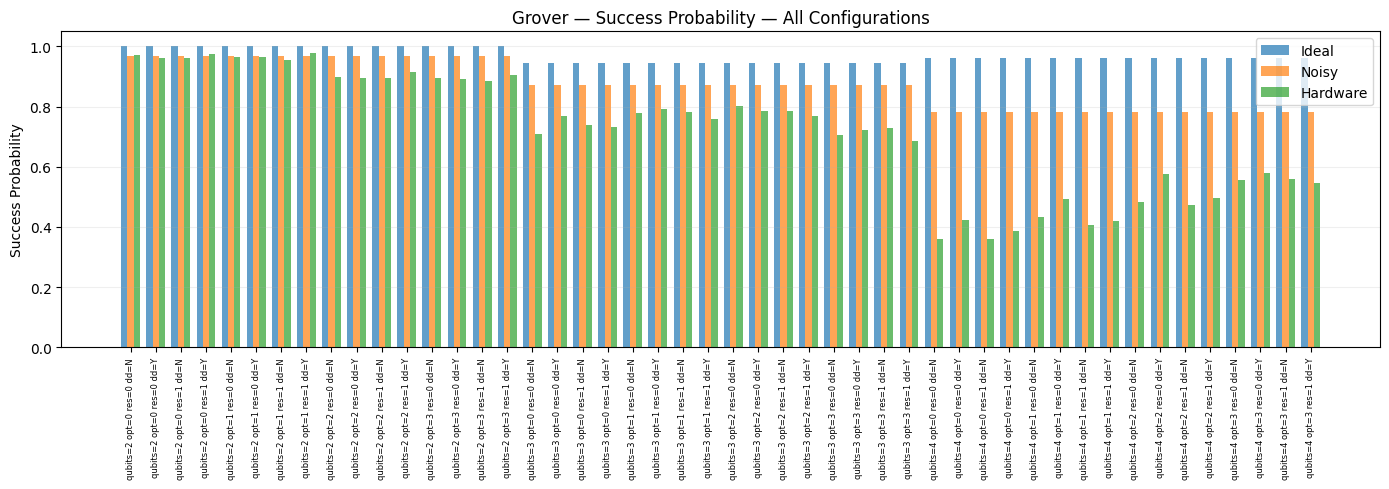

Saved ./results/grover/success_prob_bar.png


In [26]:
# ─── Bar chart: Success probability grouped by config ───
fig, ax = plt.subplots(figsize=(14, 5))

labels = []
hw_vals = []
noisy_vals = []
ideal_vals = []

for _, row in df.iterrows():
    tag = (f"qubits={row['num_qubits']} opt={row['opt_level']} "
           f"res={row['resilience_level']} dd={'Y' if row['dd_enable'] else 'N'}")
    labels.append(tag)
    hw_vals.append(row.get("hw_success_prob") or 0)
    noisy_vals.append(row.get("noisy_success_prob") or 0)
    ideal_vals.append(row.get("ideal_success_prob") or 0)

x = np.arange(len(labels))
w = 0.25
ax.bar(x - w, ideal_vals, w, label="Ideal", alpha=0.7)
ax.bar(x,     noisy_vals, w, label="Noisy", alpha=0.7)
ax.bar(x + w, hw_vals,    w, label="Hardware", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=90, fontsize=6)
ax.set_ylabel("Success Probability")
ax.set_title("Grover — Success Probability — All Configurations")
ax.legend()
ax.grid(True, alpha=0.2, axis="y")
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "success_prob_bar.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {os.path.join(OUTPUT_DIR, 'success_prob_bar.png')}")

In [27]:
# ─── Summary Table ───
summary_cols = [
    "run_id", "num_qubits", "num_iterations", "marked_state",
    "opt_level", "resilience_level", "dd_enable",
    "depth_2q", "count_2q",
    "ideal_success_prob", "noisy_success_prob",
    "hw_success_prob", "tvd_hw_vs_ideal", "tvd_noisy_vs_ideal",
    "hw_amplification", "job_id",
]
existing_cols = [c for c in summary_cols if c in df.columns]
try:
    display(df[existing_cols].style.format(precision=4, na_rep="—").set_caption(
        f"Grover (marked states: {MARKED_STATES}) — Experiment Summary"))
except AttributeError:
    # jinja2 not installed — fall back to plain DataFrame display
    display(df[existing_cols])

,run_id,num_qubits,num_iterations,marked_state,opt_level,resilience_level,dd_enable,depth_2q,count_2q,ideal_success_prob,noisy_success_prob,hw_success_prob,tvd_hw_vs_ideal,tvd_noisy_vs_ideal,hw_amplification,job_id
0,run-0001,2,1,3,0,0,False,2,2,1.0000,0.9688,0.9727,0.0273,0.0312,3.8906,d76853u8faus73f0v1f0
1,run-0002,2,1,3,0,0,True,2,2,1.0000,0.9688,0.9629,0.0371,0.0312,3.8516,d76855m8faus73f0v1h0
2,run-0003,2,1,3,0,1,False,2,2,1.0000,0.9688,0.9600,0.0400,0.0312,3.8398,d7685a68faus73f0v1n0
3,run-0004,2,1,3,0,1,True,2,2,1.0000,0.9688,0.9756,0.0244,0.0312,3.9023,d7685ce8faus73f0v1q0
4,run-0005,2,1,3,1,0,False,2,2,1.0000,0.9688,0.9639,0.0361,0.0312,3.8555,d7685enq1anc738d92c0
5,run-0006,2,1,3,1,0,True,2,2,1.0000,0.9688,0.9658,0.0342,0.0312,3.8633,d7685gu8faus73f0v20g
6,run-0007,2,1,3,1,1,False,2,2,1.0000,0.9688,0.9551,0.0449,0.0312,3.8203,d7685ja3qcgc73fsks4g
7,run-0008,2,1,3,1,1,True,2,2,1.0000,0.9688,0.9766,0.0234,0.0312,3.9062,d7685llbjrds73ed9m20
8,run-0009,2,1,3,2,0,False,2,2,1.0000,0.9688,0.8984,0.1016,0.0312,3.5938,d7685nm8faus73f0v2a0
9,run-0010,2,1,3,2,0,True,2,2,1.0000,0.9688,0.8955,0.1045,0.0312,3.5820,d7685pa3qcgc73fsksc0


---
## Search Verification & Amplification Analysis

Using the **best hardware run** (highest success probability), verify that Grover's algorithm successfully amplified the marked state above the random-guessing baseline.

1. Select the run with the highest hardware success probability.
2. Compare P(marked state) against the random baseline $1/2^n$.
3. Compute the amplification ratio — how many times better than random guessing.
4. Plot the probability distribution highlighting the marked state.

Best run: run-0008  (qubits=2, marked=|11⟩, opt=1, res=1, dd=ON)
  Random guessing baseline: 0.2500
  Measured P(|11⟩):  0.9766
  Amplification ratio:       3.91x
  *** Grover search SUCCESSFUL ***


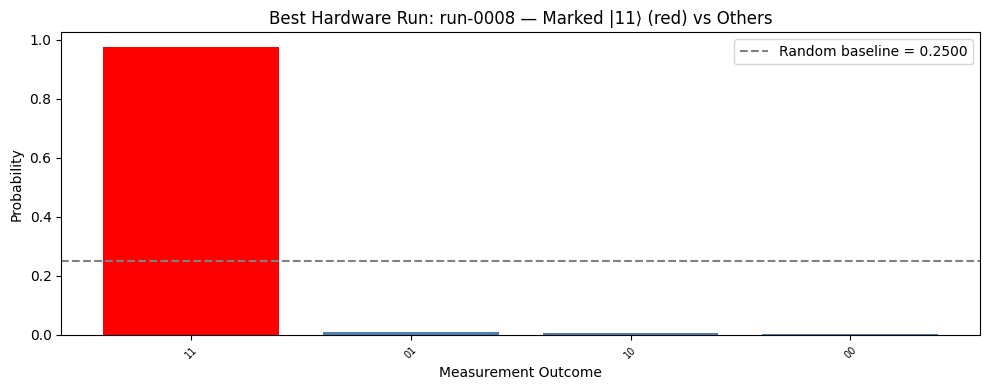

Saved ./results/grover/search_verification.png


In [28]:
# ─── Search Verification from Best Hardware Run ───

if RUN_HARDWARE and df["hw_success_prob"].notna().any():
    best_row = df.loc[df["hw_success_prob"].idxmax()]
    best_id  = best_row["run_id"]
    best_nq  = int(best_row["num_qubits"])
    best_marked = int(best_row["marked_state"])
    hw_dist  = all_distributions.get(best_id, {}).get("hardware", {})

    if hw_dist:
        marked_bs = format(best_marked, f'0{best_nq}b')
        random_p  = 1.0 / (2 ** best_nq)
        measured_p = hw_dist.get(marked_bs, 0.0)
        amp_ratio  = measured_p / random_p if random_p > 0 else 0.0

        print(f"Best run: {best_id}  (qubits={best_nq}, "
              f"marked=|{marked_bs}⟩, opt={int(best_row['opt_level'])}, "
              f"res={int(best_row['resilience_level'])}, "
              f"dd={'ON' if best_row['dd_enable'] else 'OFF'})")
        print(f"  Random guessing baseline: {random_p:.4f}")
        print(f"  Measured P(|{marked_bs}⟩):  {measured_p:.4f}")
        print(f"  Amplification ratio:       {amp_ratio:.2f}x")
        print(f"  *** Grover search {'SUCCESSFUL' if measured_p > random_p else 'FAILED'} ***")

        # Histogram of best run
        fig, ax = plt.subplots(figsize=(10, 4))
        sorted_dist = dict(sorted(hw_dist.items(),
                                  key=lambda x: x[1], reverse=True)[:20])
        colors = ['red' if k == marked_bs else 'steelblue'
                  for k in sorted_dist]
        ax.bar(sorted_dist.keys(), sorted_dist.values(), color=colors)
        ax.axhline(y=random_p, color='gray', linestyle='--',
                   label=f'Random baseline = {random_p:.4f}')
        ax.set_xlabel("Measurement Outcome")
        ax.set_ylabel("Probability")
        ax.set_title(f"Best Hardware Run: {best_id} — "
                     f"Marked |{marked_bs}⟩ (red) vs Others")
        ax.legend()
        plt.xticks(rotation=45, fontsize=7)
        plt.tight_layout()
        fig.savefig(os.path.join(OUTPUT_DIR, "search_verification.png"),
                    dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved {os.path.join(OUTPUT_DIR, 'search_verification.png')}")
    else:
        print("No hardware distribution available for search verification.")
else:
    print("Hardware runs were disabled or produced no results. "
          "Set RUN_HARDWARE = True and re-run the experiment sweep.")

---
## How to Run on IBM Hardware

### 1. Set Up Your IBM Quantum Account

```python
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="YOUR_TOKEN_HERE",
    overwrite=True,
)
```

Or place your token in `apikey.json` (the notebook will read it automatically):
```json
{"apikey": "YOUR_TOKEN_HERE"}
```

### 2. Choose a Backend

Edit the `BACKEND_NAME` variable in the **Configuration** cell.  Set it to `None` to auto-select the least-busy backend with enough qubits.

### 3. Run the Notebook

Execute all cells top-to-bottom (`Run All`).  Hardware jobs will print their **job ID** so you can monitor them in the [IBM Quantum Dashboard](https://quantum.cloud.ibm.com/).

### 4. Check Outputs

| File | Content |
|------|---------|
| `results/grover/grover_results.csv` | Flat table with all metrics per run |
| `results/grover/grover_results.json` | Full distributions + metadata |
| `results/grover/success_prob_and_tvd.png` | Line plots of success prob & TVD |
| `results/grover/success_prob_bar.png` | Bar chart across all configs |
| `results/grover/search_verification.png` | Best-run histogram with marked state highlighted |

### Tips
- Set `RUN_HARDWARE = False` to quickly iterate on the analysis pipeline using only simulations.
- Reduce `QUBIT_SWEEP` or `OPT_LEVEL_SWEEP` to shorten experiment time.
- Hardware jobs may queue; you can retrieve results later via `service.job(job_id)`.
- Compare results against Shor's data in `results/results.csv` — the `depth_2q`, `success_prob`, and `tvd_vs_ideal` columns are directly comparable.